In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud jupyter


   ----------- ---------------------------- 2/7 [lark]
   ----------- ---------------------------- 2/7 [lark]
   ---------------------- ----------------- 4/7 [rfc3987-syntax]
   ---------------------------------- ----- 6/7 [isoduration]
   ---------------------------------------- 7/7 [isoduration]

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("data/raw/amazon_reviews.csv")

In [4]:
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [5]:
df.shape

(23486, 11)

In [6]:
df.columns

Index(['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [8]:
df.describe(include="all")

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
count,23486.000000,23486.000000,23486.000000,19676,22641,23486.000000,23486.000000,23486.000000,23472,23472,23472
unique,NaN,NaN,NaN,13993,22634,NaN,NaN,NaN,3,6,20
top,NaN,NaN,NaN,Love it!,Perfect fit and i've gotten so many compliment...,NaN,NaN,NaN,General,Tops,Dresses
freq,NaN,NaN,NaN,136,3,NaN,NaN,NaN,13850,10468,6319
mean,11742.500000,918.118709,43.198544,NaN,NaN,4.196032,0.822362,2.535936,NaN,NaN,NaN
std,6779.968547,203.298980,12.279544,NaN,NaN,1.110031,0.382216,5.702202,NaN,NaN,NaN
min,0.000000,0.000000,18.000000,NaN,NaN,1.000000,0.000000,0.000000,NaN,NaN,NaN
25%,5871.250000,861.000000,34.000000,NaN,NaN,4.000000,1.000000,0.000000,NaN,NaN,NaN
50%,11742.500000,936.000000,41.000000,NaN,NaN,5.000000,1.000000,1.000000,NaN,NaN,NaN
75%,17613.750000,1078.000000,52.000000,NaN,NaN,5.000000,1.000000,3.000000,NaN,NaN,NaN


In [9]:
df.sample(5)

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
14495,14495,909,49,Returned,"The fit was not flattering at all, but the wor...",1,0,0,General,Tops,Fine gauge
21539,21539,1094,28,Super cute but large,"As other reviewers have mentioned, this dress ...",4,1,0,General Petite,Dresses,Dresses
23112,23112,1083,41,Weird bulge in the back zipper?,I just scoured the other reviews to see if any...,4,1,1,General,Dresses,Dresses
14049,14049,864,56,Amazing,Perfect for work or a night out. packing for e...,5,1,0,General Petite,Tops,Knits
19099,19099,453,34,Please stop going down in fabric quality,"I've been wearing these shorts for years, i wo...",2,0,3,General,Bottoms,Shorts


# Day 1

## Objective
Understand the dataset and explore its structure.

### Tasks Completed
- Imported libraries
- Loaded dataset
- Viewed first few rows
- Checked dataset dimensions
- Examined columns and data types

In [10]:
df.isnull().sum()

Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

In [11]:
df.isnull().sum()

Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

In [12]:
df.duplicated().sum()

0

In [13]:
df.nunique()

Unnamed: 0                 23486
Clothing ID                 1206
Age                           77
Title                      13993
Review Text                22634
Rating                         5
Recommended IND                2
Positive Feedback Count       82
Division Name                  3
Department Name                6
Class Name                    20
dtype: int64

In [14]:
df["Review Text"].head()

0    Absolutely wonderful - silky and sexy and comf...
1    Love this dress!  it's sooo pretty.  i happene...
2    I had such high hopes for this dress and reall...
3    I love, love, love this jumpsuit. it's fun, fl...
4    This shirt is very flattering to all due to th...
Name: Review Text, dtype: object

In [15]:
df["Rating"].value_counts()

Rating
5    13131
4     5077
3     2871
2     1565
1      842
Name: count, dtype: int64

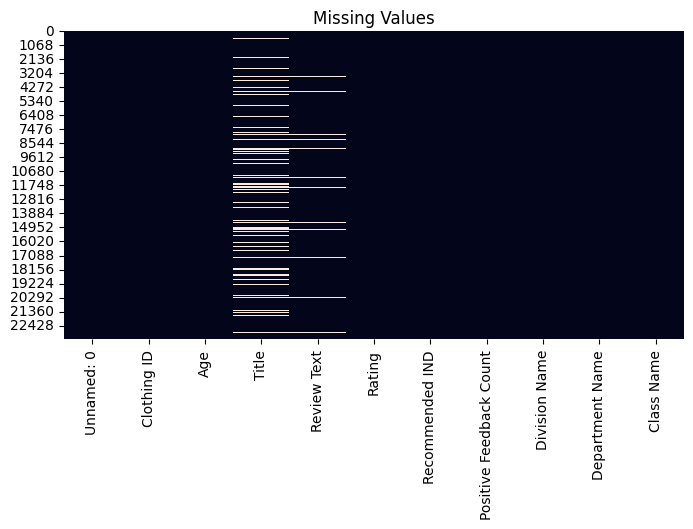

In [16]:
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

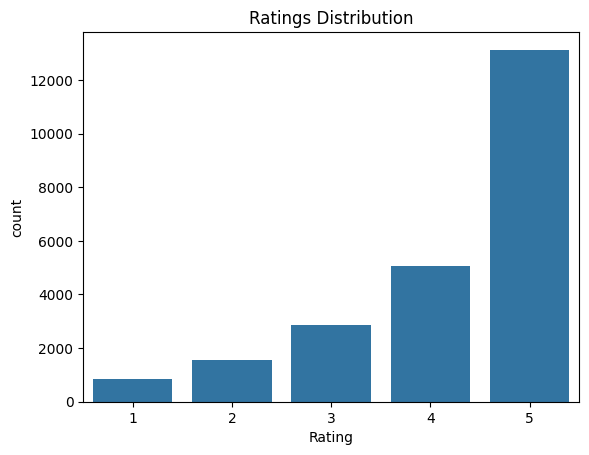

In [17]:
sns.countplot(x="Rating", data=df)
plt.title("Ratings Distribution")
plt.show()

# Day 2

## Objective
Understand data quality and identify potential issues.

### Tasks Completed
- Checked missing values
- Checked duplicates
- Counted unique values
- Examined review text
- Visualized rating distribution

# Customer Review Sentiment Analysis using NLP

## Author
Pooja Manjunath

## Objective
Build an end-to-end Sentiment Analysis model using Natural Language Processing and Machine Learning.

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- NLTK
- Scikit-learn
- WordCloud

### Dataset
Amazon Customer Reviews Dataset

### Problem Statement
Businesses receive thousands of customer reviews daily. This project analyzes review text and predicts whether a review is Positive, Negative, or Neutral using NLP and Machine Learning techniques.

In [4]:
df.isnull().sum()

Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

In [5]:
df = df.dropna()

In [6]:
df.isnull().sum()

Unnamed: 0                 0
Clothing ID                0
Age                        0
Title                      0
Review Text                0
Rating                     0
Recommended IND            0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.drop_duplicates()

In [10]:
df.dtypes

Unnamed: 0                  int64
Clothing ID                 int64
Age                         int64
Title                      object
Review Text                object
Rating                      int64
Recommended IND             int64
Positive Feedback Count     int64
Division Name              object
Department Name            object
Class Name                 object
dtype: object

In [11]:
df.to_csv("data/processed/cleaned_reviews.csv", index=False)

# Day 3

## Objective

Perform data cleaning.

### Tasks Completed

- Removed missing values
- Removed duplicate records
- Verified data types
- Saved cleaned dataset

In [12]:
import re
import string

In [13]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [14]:
df["Clean_Review"] = df["Review Text"].apply(clean_text)

In [15]:
df[["Review Text","Clean_Review"]].head()

,Review Text,Clean_Review
2,I had such high hopes for this dress and reall...,i had such high hopes for this dress and reall...
3,"I love, love, love this jumpsuit. it's fun, fl...",i love love love this jumpsuit its fun flirty ...
4,This shirt is very flattering to all due to th...,this shirt is very flattering to all due to th...
5,"I love tracy reese dresses, but this one is no...",i love tracy reese dresses but this one is not...
6,I aded this in my basket at hte last mintue to...,i aded this in my basket at hte last mintue to...


# Day 4

## Objective

Clean customer review text.

### Tasks Completed

- Converted text to lowercase
- Removed punctuation
- Removed numbers
- Removed URLs
- Removed HTML tags